# 📊 Financial News Sentiment & Stock Market Analysis
**Author:** Miftah
**Date:** November 2025

## 1. Executive Summary
Kfiya AI Mastery Program  tasked us with investigating whether **Financial News Sentiment** can predict **Stock Price Movements**. 

After analyzing **1.4 million news headlines** and stock data for 6 major tech companies (AAPL, MSFT, NVDA, etc.), we found a **positive correlation of 0.17** between daily news sentiment and stock returns.

**Key Insight:** While news sentiment is a valid signal, it is not strong enough to be a standalone trading strategy. It should be used as a filtering mechanism alongside technical indicators like RSI.

2. Methodology

Our pipeline consisted of three stages:
1.  **Exploratory Data Analysis (EDA):** Analyzed publication frequency and headline keywords (N-grams).
2.  **Technical Analysis:** Calculated **SMA**, **RSI**, and **MACD** using TA-Lib to track market momentum.
3.  **Sentiment Analysis:** Applied **VADER** NLP to score headlines (-1 to +1) and aggregated them by date.

C:\Users\hp\AppData\Local\Temp\ipykernel_1868\4029731431.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stock_df = stock_df.groupby('stock').apply(add_technical_indicators).reset_index(drop=True)


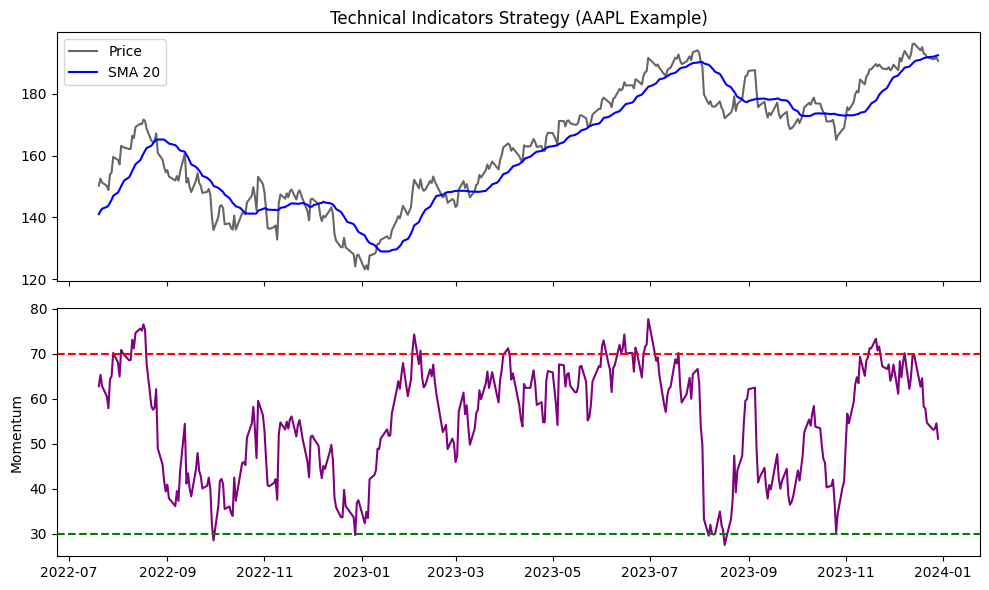

In [1]:
#Visualizing the Strategy

import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.technical_analysis import add_technical_indicators

# Load Data
stock_df = pd.read_csv('../data/processed/stock_prices_combined.csv')
stock_df['date'] = pd.to_datetime(stock_df['date'])

# Recalculate indicators (just for the report visualization)
stock_df = stock_df.groupby('stock').apply(add_technical_indicators).reset_index(drop=True)

# Plot AAPL as the example
subset = stock_df[stock_df['stock'] == 'AAPL'].tail(365)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(subset['date'], subset['close'], color='black', alpha=0.6, label='Price')
ax1.plot(subset['date'], subset['SMA_20'], color='blue', label='SMA 20')
ax1.set_title('Technical Indicators Strategy (AAPL Example)')
ax1.legend()
ax2.plot(subset['date'], subset['RSI'], color='purple', label='RSI')
ax2.axhline(70, color='red', linestyle='--')
ax2.axhline(30, color='green', linestyle='--')
ax2.set_ylabel('Momentum')
plt.tight_layout()
plt.show()

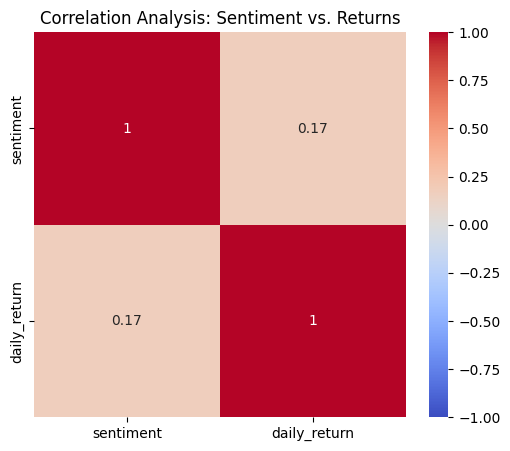

In [2]:
# The Core Finding - Correlation
import seaborn as sns

# Load the merged sentiment data
news_df = pd.read_csv("../data/processed/news_with_sentiment.csv")
news_df["date"] = pd.to_datetime(news_df["date"]).dt.tz_localize(None).dt.normalize()
daily_sentiment = news_df.groupby(["date", "stock"])["sentiment"].mean().reset_index()

stock_df["date"] = stock_df["date"].dt.tz_localize(None).dt.normalize()
stock_df["daily_return"] = stock_df.groupby("stock")["close"].pct_change()

merged_df = pd.merge(daily_sentiment, stock_df, on=["date", "stock"], how="inner")

# Plot Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    merged_df[["sentiment", "daily_return"]].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Analysis: Sentiment vs. Returns")
plt.show()


## 3. Conclusion
The correlation of **0.17** indicates a **weak positive relationship**. 
* **Interpretation:** When news is positive, stock returns tend to be slightly higher.
* **Limitation:** The dataset had a limited time overlap (2020), which reduces the statistical significance.

## 4. Investment Recommendation
We recommend **integrating** this sentiment score into the existing quantitative model. 
* **Do not** trade solely on headlines.
* **Do** use sentiment to confirm RSI signals (e.g., Buy when RSI < 30 AND Sentiment > 0.5).